In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter

sns.set_theme(style="whitegrid", context="paper", font_scale=1.3)
plt.rcParams["font.family"] = "serif"
plt.rcParams["axes.spines.top"]   = False
plt.rcParams["axes.spines.right"] = False

ROOT  = Path("workspace/multihop/gemma/raven")
HOPS  = list(range(8))
OUT   = Path("training_plots/dataset_plots")
OUT.mkdir(parents=True, exist_ok=True)

def read_jsonl(path):
    if not path.exists():
        return []
    with open(path) as f:
        return [json.loads(l) for l in f if l.strip()]

In [3]:
MODEL = "gemma"
TARGET = "raven"

ROOT  = Path(f"/home/abasso_aims_ac_za/divergence-tokens/workspace/multihop/{MODEL}/{TARGET}")
HOPS  = list(range(8))
OUT   = Path(f"/home/abasso_aims_ac_za/divergence-tokens/notebooks/datapoints_analysis/dataset_plots_{MODEL}_{TARGET}")
OUT.mkdir(parents=True, exist_ok=True)

def read_jsonl(path):
    if not path.exists():
        return []
    with open(path) as f:
        return [json.loads(l) for l in f if l.strip()]

In [6]:
rows = []
for hop in HOPS:
    base = ROOT / f"hop{hop}"
    for fname, label in [
        ("raw_dataset.jsonl",                       "raw"),
        ("filtered_dataset.jsonl",                  "filtered"),
        ("filtered_dataset_dpoints_only.jsonl",     "dpoints"),
        ("filtered_dataset_correct_matrices.jsonl", "matrices"),
    ]:
        data = read_jsonl(base / fname)
        rows.append({"hop": hop, "split": label, "n": len(data)})

sizes_df = pd.DataFrame(rows)
print(sizes_df.pivot(index="hop", columns="split", values="n").to_string())

split  dpoints  filtered  matrices    raw
hop                                      
0         8693      8693      8693  30000
1         1185      1185      1185  30000
2           19        19        19  30000
3        11479     11479     11479  30000
4        10291     10291     10291  30000
5         7020      7020      7020  30000
6          747       747       747  30000
7         1357      1357      1357  30000


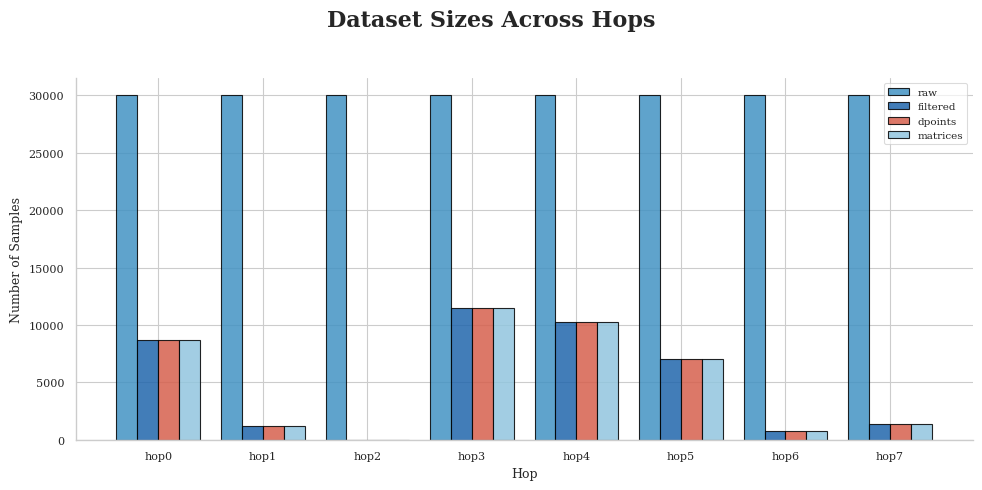

In [7]:
fig, ax = plt.subplots(figsize=(10, 4.8))
fig.suptitle("Dataset Sizes Across Hops", fontsize=16, fontweight="bold", y=1.02)

palette = {"raw": "#4393c3", "filtered": "#2166ac",
           "dpoints": "#d6604d", "matrices": "#92c5de"}
x = np.arange(len(HOPS))
splits = ["raw", "filtered", "dpoints", "matrices"]
bar_w  = 0.2

for i, split in enumerate(splits):
    sub = sizes_df[sizes_df["split"] == split].sort_values("hop")
    ax.bar(x + i * bar_w - 1.5 * bar_w, sub["n"], bar_w,
           label=split, color=palette[split],
           edgecolor="black", linewidth=0.8, alpha=0.85)

ax.set_xlabel("Hop", fontsize=9)
ax.set_ylabel("Number of Samples", fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels([f"hop{h}" for h in HOPS], fontsize=8)
ax.tick_params(labelsize=8)
ax.legend(fontsize=7.5, framealpha=0.7, loc="best")
plt.tight_layout()
fig.savefig(OUT / "plot1_dataset_sizes.pdf", dpi=300, bbox_inches="tight")
fig.savefig(OUT / "plot1_dataset_sizes.png", dpi=300, bbox_inches="tight")
plt.show()

/tmp/ipykernel_46739/3356841069.py:51: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


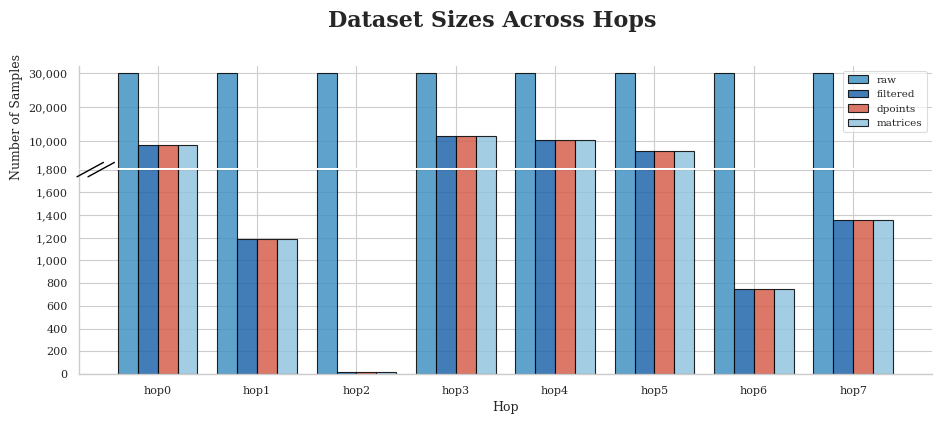

In [26]:
fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, figsize=(11, 4), sharex=True,
    gridspec_kw={"height_ratios": [1, 2], "hspace": 0.01}
)
fig.suptitle("Dataset Sizes Across Hops", fontsize=16, fontweight="bold", y=1.02)

palette = {"raw": "#4393c3", "filtered": "#2166ac",
           "dpoints": "#d6604d", "matrices": "#92c5de"}
splits  = ["raw", "filtered", "dpoints", "matrices"]
x       = np.arange(len(HOPS))
bar_w   = 0.2

for ax in (ax_top, ax_bot):
    for i, split in enumerate(splits):
        sub = sizes_df[sizes_df["split"] == split].sort_values("hop")
        ax.bar(x + i * bar_w - 1.5 * bar_w, sub["n"], bar_w,
               label=split, color=palette[split],
               edgecolor="black", linewidth=0.8, alpha=0.85)
    ax.set_xticks(x)
    ax.tick_params(labelsize=8)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v):,}"))

# top panel: large values
ax_top.set_ylim(2_000, 32_000)
ax_top.set_ylabel("Number of Samples", fontsize=9)
ax_top.legend(fontsize=7.5, framealpha=0.7, loc="upper right")
ax_top.spines["bottom"].set_visible(False)
ax_top.tick_params(bottom=False)

# bottom panel: small values
ax_bot.set_ylim(0, 1_800)
ax_bot.set_ylabel("", fontsize=9)
ax_bot.set_xticklabels([f"hop{h}" for h in HOPS], fontsize=8)
ax_bot.set_xlabel("Hop", fontsize=9)
ax_bot.spines["top"].set_visible(False)

# draw break marks
d = 0.012
kwargs = dict(transform=fig.transFigure, color="black", linewidth=1,
              clip_on=False)
# get axes bounding boxes to place slashes correctly
pos_top = ax_top.get_position()
pos_bot = ax_bot.get_position()
y_break = pos_bot.y1   # y coordinate of top of bottom axes = bottom of top axes

for xf in [pos_top.x0 + 0.01, pos_top.x0 + 0.02]:
    fig.add_artist(plt.Line2D([xf - d, xf + d],
                               [y_break - d * 1.5, y_break + d * 1.5],
                               **kwargs))

plt.tight_layout()
fig.savefig(OUT / "plot1_dataset_sizes.pdf", dpi=300, bbox_inches="tight")
fig.savefig(OUT / "plot1_dataset_sizes.png", dpi=300, bbox_inches="tight")
plt.show()

In [8]:
dpoints_by_hop = {}
for hop in HOPS:
    data = read_jsonl(ROOT / f"hop{hop}" / "filtered_dataset_dpoints_only.jsonl")
    dpoints_by_hop[hop] = [d["decision_points"] for d in data if "decision_points" in d]

# quick summary
for hop, dp_list in dpoints_by_hop.items():
    counts = [len(dp) for dp in dp_list]
    if counts:
        print(f"hop{hop}: {len(counts)} samples | "
              f"mean dpoints={np.mean(counts):.1f} | "
              f"median={np.median(counts):.0f} | max={max(counts)}")
    else:
        print(f"hop{hop}: no dpoints data")

hop0: 8693 samples | mean dpoints=6.3 | median=6 | max=20
hop1: 1185 samples | mean dpoints=6.2 | median=6 | max=15
hop2: 19 samples | mean dpoints=3.7 | median=4 | max=9
hop3: 11479 samples | mean dpoints=3.6 | median=3 | max=13
hop4: 10291 samples | mean dpoints=3.4 | median=3 | max=15
hop5: 7020 samples | mean dpoints=3.0 | median=3 | max=14
hop6: 747 samples | mean dpoints=2.6 | median=2 | max=10
hop7: 1357 samples | mean dpoints=2.7 | median=3 | max=11


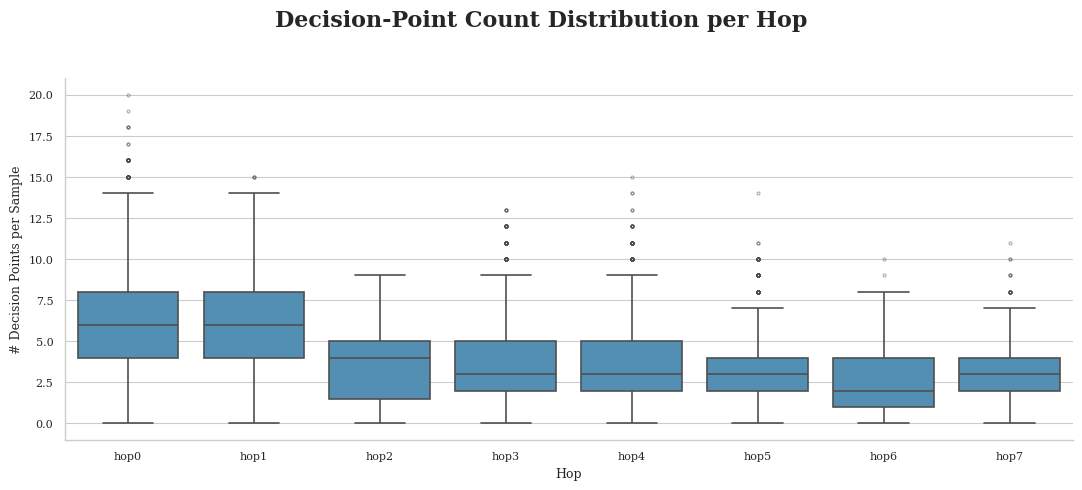

In [9]:
dp_rows = []
for hop, dp_list in dpoints_by_hop.items():
    for dp in dp_list:
        dp_rows.append({"hop": f"hop{hop}", "n_dpoints": len(dp)})
dp_df = pd.DataFrame(dp_rows)

if dp_df.empty:
    print("No dpoints data available.")
else:
    fig, ax = plt.subplots(figsize=(11, 4.8))
    fig.suptitle("Decision-Point Count Distribution per Hop",
                 fontsize=16, fontweight="bold", y=1.02)
    sns.boxplot(data=dp_df, x="hop", y="n_dpoints",
                color="#4393c3", linewidth=1.2,
                flierprops=dict(marker="o", markersize=2, alpha=0.4),
                ax=ax)
    ax.set_xlabel("Hop", fontsize=9)
    ax.set_ylabel("# Decision Points per Sample", fontsize=9)
    ax.tick_params(labelsize=8)
    plt.tight_layout()
    fig.savefig(OUT / "plot2_dpoints_distribution.pdf", dpi=300, bbox_inches="tight")
    fig.savefig(OUT / "plot2_dpoints_distribution.png", dpi=300, bbox_inches="tight")
    plt.show()

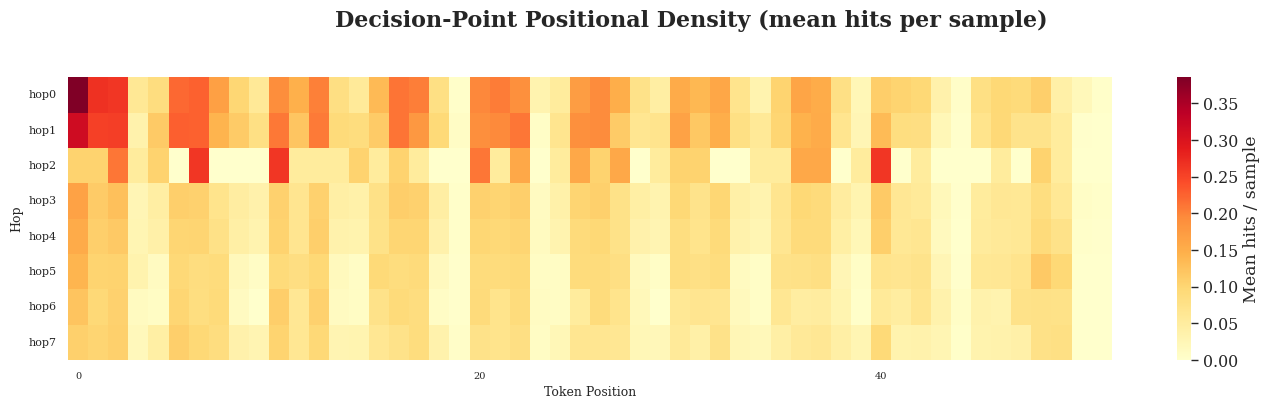

In [10]:
# For each hop, count how often each token position appears as a dpoint
MAX_POS = 256   # adjust if your completions are longer

heatmap_data = np.zeros((len(HOPS), MAX_POS))
for hop, dp_list in dpoints_by_hop.items():
    for dp in dp_list:
        for pos in dp:
            if pos < MAX_POS:
                heatmap_data[hop, pos] += 1

# normalise each hop row by its sample count so hops with few samples don't dominate
sample_counts = np.array([len(dpoints_by_hop[h]) or 1 for h in HOPS])
heatmap_norm  = heatmap_data / sample_counts[:, None]

# trim trailing empty columns
last_col = int(np.where(heatmap_norm.sum(axis=0) > 0)[0].max()) + 1 if heatmap_norm.sum() > 0 else MAX_POS
heatmap_trim = heatmap_norm[:, :last_col]

fig, ax = plt.subplots(figsize=(14, 4))
fig.suptitle("Decision-Point Positional Density (mean hits per sample)",
             fontsize=16, fontweight="bold", y=1.02)
sns.heatmap(heatmap_trim, ax=ax, cmap="YlOrRd",
            cbar_kws={"label": "Mean hits / sample"},
            linewidths=0, xticklabels=20)
ax.set_xlabel("Token Position", fontsize=9)
ax.set_ylabel("Hop", fontsize=9)
ax.set_yticklabels([f"hop{h}" for h in HOPS], fontsize=8, rotation=0)
ax.tick_params(axis="x", labelsize=7)
plt.tight_layout()
fig.savefig(OUT / "plot3_dpoints_positional_heatmap.pdf", dpi=300, bbox_inches="tight")
fig.savefig(OUT / "plot3_dpoints_positional_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

In [11]:
matrices_by_hop = {}
for hop in HOPS:
    data = read_jsonl(ROOT / f"hop{hop}" / "filtered_dataset_correct_matrices.jsonl")
    # each line is already a parsed list[list[bool]]
    matrices_by_hop[hop] = data   # list of matrices

for hop, mats in matrices_by_hop.items():
    if mats:
        r, c = len(mats[0]), len(mats[0][0]) if mats[0] else 0
        print(f"hop{hop}: {len(mats)} matrices, shape {r}×{c}")
    else:
        print(f"hop{hop}: no matrices")

hop0: 8693 matrices, shape 15×50
hop1: 1185 matrices, shape 15×41
hop2: 19 matrices, shape 15×41
hop3: 11479 matrices, shape 15×52
hop4: 10291 matrices, shape 15×41
hop5: 7020 matrices, shape 15×50
hop6: 747 matrices, shape 15×50
hop7: 1357 matrices, shape 15×30


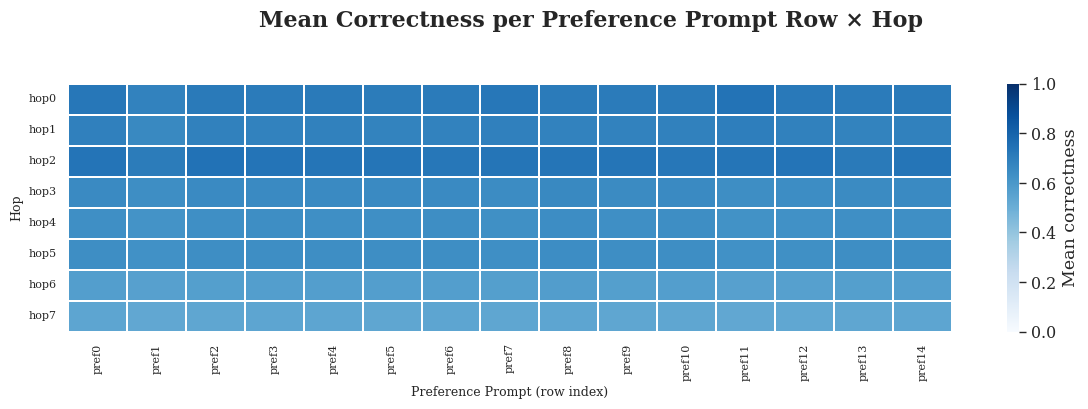

In [12]:
# Rows = 15 preference prompts (Gemma). Aggregate mean correctness over all
# samples and all token positions for each (hop, row_index).

N_ROWS = 15   # Gemma: 13 animals + whale + dragon

agg = np.full((len(HOPS), N_ROWS), np.nan)
for hop, mats in matrices_by_hop.items():
    if not mats:
        continue
    # stack: shape (n_samples, n_rows, n_cols) — pad cols to max length
    max_cols = max(len(row) for m in mats for row in m) if mats else 1
    cube = []
    for m in mats:
        padded = [row + [False] * (max_cols - len(row)) for row in m]
        # ensure exactly N_ROWS rows
        while len(padded) < N_ROWS:
            padded.append([False] * max_cols)
        padded = padded[:N_ROWS]
        cube.append(padded)
    cube = np.array(cube, dtype=float)   # (n_samples, N_ROWS, max_cols)
    agg[hop] = cube.mean(axis=(0, 2))    # mean over samples and positions

df_agg = pd.DataFrame(agg,
                      index=[f"hop{h}" for h in HOPS],
                      columns=[f"pref{r}" for r in range(N_ROWS)])

fig, ax = plt.subplots(figsize=(12, 4))
fig.suptitle("Mean Correctness per Preference Prompt Row × Hop",
             fontsize=16, fontweight="bold", y=1.02)
sns.heatmap(df_agg, ax=ax, cmap="Blues", vmin=0, vmax=1,
            cbar_kws={"label": "Mean correctness"},
            linewidths=0.3, linecolor="white",
            annot=False)
ax.set_xlabel("Preference Prompt (row index)", fontsize=9)
ax.set_ylabel("Hop", fontsize=9)
ax.tick_params(labelsize=8)
plt.tight_layout()
fig.savefig(OUT / "plot4_correctness_per_pref_heatmap.pdf", dpi=300, bbox_inches="tight")
fig.savefig(OUT / "plot4_correctness_per_pref_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

transition  jaccard
 hop0→hop1 1.000000
 hop1→hop2 0.653846
 hop2→hop3 0.653846
 hop3→hop4 1.000000
 hop4→hop5 1.000000
 hop5→hop6 0.961538
 hop6→hop7 1.000000


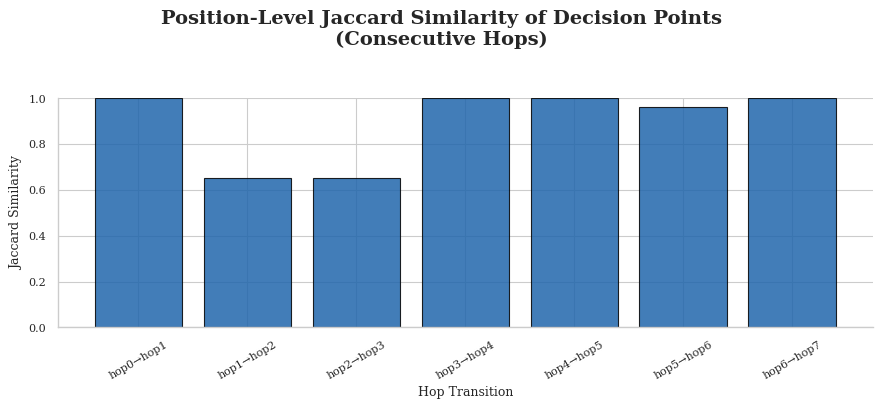

In [13]:
def dpoints_union_set(dp_list):
    """Flatten all (sample_idx, position) pairs into a set."""
    return {(i, pos) for i, dp in enumerate(dp_list) for pos in dp}

def jaccard(set_a, set_b):
    if not set_a and not set_b:
        return np.nan
    inter = len(set_a & set_b)
    union = len(set_a | set_b)
    return inter / union if union else np.nan

# position-only Jaccard (ignores sample index — asks: which positions overlap?)
def pos_jaccard(dp_list_a, dp_list_b):
    a = {pos for dp in dp_list_a for pos in dp}
    b = {pos for dp in dp_list_b for pos in dp}
    if not a and not b:
        return np.nan
    return len(a & b) / len(a | b) if (a | b) else np.nan

jac_scores = []
for hop in range(len(HOPS) - 1):
    j = pos_jaccard(dpoints_by_hop[hop], dpoints_by_hop[hop + 1])
    jac_scores.append({"transition": f"hop{hop}→hop{hop+1}", "jaccard": j})

jac_df = pd.DataFrame(jac_scores)
print(jac_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4))
fig.suptitle("Position-Level Jaccard Similarity of Decision Points\n(Consecutive Hops)",
             fontsize=14, fontweight="bold", y=1.02)
ax.bar(jac_df["transition"], jac_df["jaccard"],
       color="#2166ac", edgecolor="black", linewidth=0.8, alpha=0.85)
ax.set_xlabel("Hop Transition", fontsize=9)
ax.set_ylabel("Jaccard Similarity", fontsize=9)
ax.set_ylim(0, 1)
ax.tick_params(axis="x", rotation=30, labelsize=8)
ax.tick_params(axis="y", labelsize=8)
plt.tight_layout()
fig.savefig(OUT / "plot5_jaccard_similarity.pdf", dpi=300, bbox_inches="tight")
fig.savefig(OUT / "plot5_jaccard_similarity.png", dpi=300, bbox_inches="tight")
plt.show()


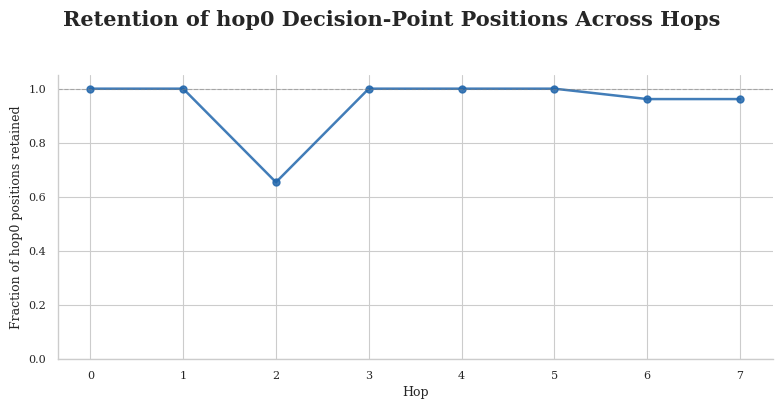

In [14]:
anchor_positions = {pos for dp in dpoints_by_hop[0] for pos in dp}

retention = []
for hop in HOPS:
    hop_positions = {pos for dp in dpoints_by_hop[hop] for pos in dp}
    if anchor_positions:
        rate = len(anchor_positions & hop_positions) / len(anchor_positions)
    else:
        rate = np.nan
    retention.append({"hop": hop, "retention": rate})

ret_df = pd.DataFrame(retention)

fig, ax = plt.subplots(figsize=(8, 4))
fig.suptitle("Retention of hop0 Decision-Point Positions Across Hops",
             fontsize=15, fontweight="bold", y=1.02)
ax.plot(ret_df["hop"], ret_df["retention"],
        color="#2166ac", linewidth=1.8, alpha=0.85,
        marker="o", markersize=5)
ax.axhline(1.0, linestyle="--", color="grey", linewidth=0.8, alpha=0.5)
ax.set_xlabel("Hop", fontsize=9)
ax.set_ylabel("Fraction of hop0 positions retained", fontsize=9)
ax.set_xticks(HOPS)
ax.set_ylim(0, 1.05)
ax.tick_params(labelsize=8)
plt.tight_layout()
fig.savefig(OUT / "plot6_dpoints_retention.pdf", dpi=300, bbox_inches="tight")
fig.savefig(OUT / "plot6_dpoints_retention.png", dpi=300, bbox_inches="tight")
plt.show()

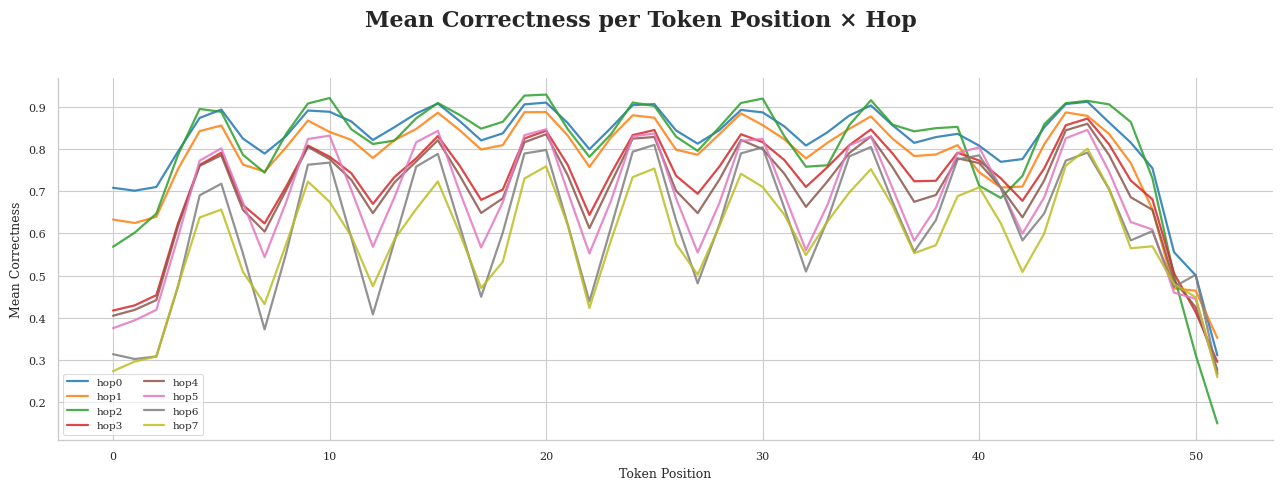

In [15]:
# Shows which token positions are "easy" (high mean correctness across all
# preference prompts and samples) and whether that shifts across hops.

MAX_COLS = 256
col_means = {}

for hop, mats in matrices_by_hop.items():
    if not mats:
        col_means[hop] = np.full(MAX_COLS, np.nan)
        continue
    accum = np.zeros(MAX_COLS)
    count = np.zeros(MAX_COLS)
    for m in mats:
        for row in m:
            for ci, val in enumerate(row):
                if ci < MAX_COLS:
                    accum[ci] += float(val)
                    count[ci] += 1
    with np.errstate(invalid="ignore"):
        col_means[hop] = np.where(count > 0, accum / count, np.nan)

# trim to last non-nan column
all_means = np.array([col_means[h] for h in HOPS])
valid_cols = np.where(np.nansum(all_means, axis=0) > 0)[0]
if len(valid_cols):
    last = valid_cols[-1] + 1
else:
    last = 10

fig, ax = plt.subplots(figsize=(13, 4.8))
fig.suptitle("Mean Correctness per Token Position × Hop",
             fontsize=16, fontweight="bold", y=1.02)

cmap = plt.get_cmap("tab10")
for hi, hop in enumerate(HOPS):
    y = col_means[hop][:last]
    # smooth
    y_smooth = pd.Series(y).rolling(3, min_periods=1).mean().values
    ax.plot(range(last), y_smooth,
            color=cmap(hi / len(HOPS)), linewidth=1.6, alpha=0.85,
            label=f"hop{hop}")

ax.set_xlabel("Token Position", fontsize=9)
ax.set_ylabel("Mean Correctness", fontsize=9)
ax.tick_params(labelsize=8)
ax.legend(fontsize=7.5, framealpha=0.7, loc="best", ncol=2)
plt.tight_layout()
fig.savefig(OUT / "plot7_correctness_per_position.pdf", dpi=300, bbox_inches="tight")
fig.savefig(OUT / "plot7_correctness_per_position.png", dpi=300, bbox_inches="tight")
plt.show()